In [24]:
import time, math
from dataclasses import dataclass
import numpy as np
import torch

from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("device:", device)


device: cuda


In [17]:
# layer helper classes
@dataclass
class Dense:
    out: int

@dataclass
class Conv:
    out_channels: int
    kernel_size: int = 3
    stride: int = 1
    padding: int = 0

@dataclass
class Flatten:
    _: str = None

def addLayer(spec, input_shape, layers):
    if isinstance(spec, Conv):
        c, h, w = input_shape

        layers += [
            nn.Conv2d(
                in_channels=c,
                out_channels=spec.out_channels,
                kernel_size=spec.kernel_size,
                stride=spec.stride,
                padding=spec.padding,
            ),
            nn.ReLU(),
        ]

        h = (h + 2 * spec.padding - spec.kernel_size) // spec.stride + 1
        w = (w + 2 * spec.padding - spec.kernel_size) // spec.stride + 1
        output_shape = (spec.out_channels, h, w)

    elif isinstance(spec, Dense):
        if len(input_shape) == 3:
            c, h, w = input_shape
            layers.append(nn.Flatten())
            in_features = c * h * w
        else:
            in_features = input_shape[0]

        layers += [
            nn.Linear(in_features, spec.out),
            nn.ReLU(),
        ]
        output_shape = (spec.out,)
    
    elif isinstance(spec, Flatten):
        layers.append(nn.Flatten())
        output_shape = (int(np.prod(input_shape)),)
    else:
        raise TypeError(f"Unknown layer spec: {spec}")
    
    return output_shape

In [30]:
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EPOCHS = 11

ARCH = [
    Conv(8, 3),
    Dense(32)
]

VALIDATION_FRAC = 0.2

OPTIMIZER = "adam"

RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)

In [31]:
transform = transforms.ToTensor()

train_full = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform,
)

n_train = int((1.0 - VALIDATION_FRAC) * len(train_full))
n_val = len(train_full) - n_train

train_dataset, val_dataset = random_split(
    train_full,
    [n_train, n_val],
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [33]:
class Model(nn.Module):

    def __init__(self, arch: list):
        super().__init__()

        shape = (1, 28, 28)
        
        layers = []
        for L in arch:
            shape = addLayer(L, shape, layers)

        if len(shape) == 3:
            shape = addLayer(Flatten(), shape, layers)

        # output layer
        layers.append(nn.Linear(int(np.prod(shape)), 10))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# create model object
model = Model(ARCH)

model.to(device)
loss_fn = nn.CrossEntropyLoss()

# set optimizaton method
if OPTIMIZER.lower() == "sgd":
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE,
    )

elif OPTIMIZER.lower() == "adam":
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )

else:
    raise ValueError("unknown optimizer")

# learning rate decay?
scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer,
    gamma=0.95,
)

In [34]:
train_loss_curve = []
val_loss_curve = []

for epoch in range(EPOCHS):

    # =========================
    # TRAINING MODE
    # =========================
    model.train()

    running_loss = 0.0

    for X, y in train_loader:

        X = X.to(device)
        y = y.to(device)

        # forward pass
        logits = model(X)

        # loss
        loss = loss_fn(logits, y)

        # reset gradients
        optimizer.zero_grad()

        # backprop
        loss.backward()

        # parameter update
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_loss_curve.append(train_loss)

    # =========================
    # VALIDATION MODE
    # =========================
    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for X, y in val_loader:

            X = X.to(device)
            y = y.to(device)

            logits = model(X)

            loss = loss_fn(logits, y)

            running_val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    val_loss = running_val_loss / len(val_loader)
    val_acc = correct / total

    val_loss_curve.append(val_loss)

    print(
        f"Epoch {epoch+1:2d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={100*val_acc:.2f}%"
    )

Epoch  1 | train_loss=0.3093 | val_loss=0.1857 | val_acc=94.48%
Epoch  2 | train_loss=0.1472 | val_loss=0.1488 | val_acc=95.40%
Epoch  3 | train_loss=0.1053 | val_loss=0.1069 | val_acc=96.74%
Epoch  4 | train_loss=0.0804 | val_loss=0.0946 | val_acc=97.17%
Epoch  5 | train_loss=0.0638 | val_loss=0.0873 | val_acc=97.47%
Epoch  6 | train_loss=0.0505 | val_loss=0.0841 | val_acc=97.53%
Epoch  7 | train_loss=0.0408 | val_loss=0.0862 | val_acc=97.52%
Epoch  8 | train_loss=0.0328 | val_loss=0.0919 | val_acc=97.29%
Epoch  9 | train_loss=0.0271 | val_loss=0.0824 | val_acc=97.76%
Epoch 10 | train_loss=0.0220 | val_loss=0.0953 | val_acc=97.53%
Epoch 11 | train_loss=0.0178 | val_loss=0.1003 | val_acc=97.57%


In [35]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device)
        y = y.to(device)

        logits = model(X)

        preds = torch.argmax(logits, dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

accuracy = 100.0 * correct / total

print(f"test accuracy: {accuracy:.2f}%")

test accuracy: 97.76%


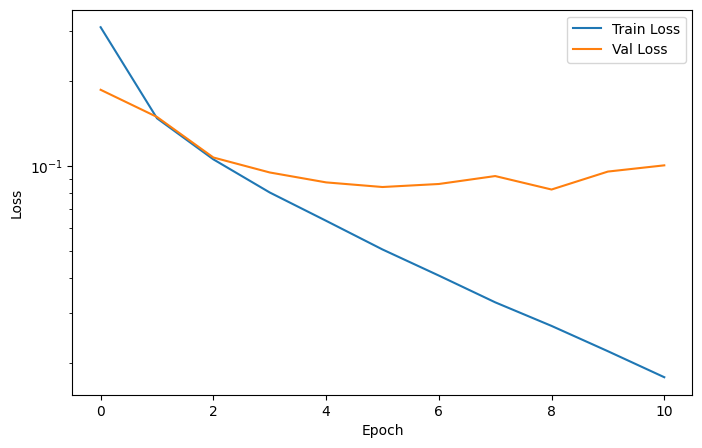

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(train_loss_curve, label="Train Loss")
plt.plot(val_loss_curve, label="Val Loss")

plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

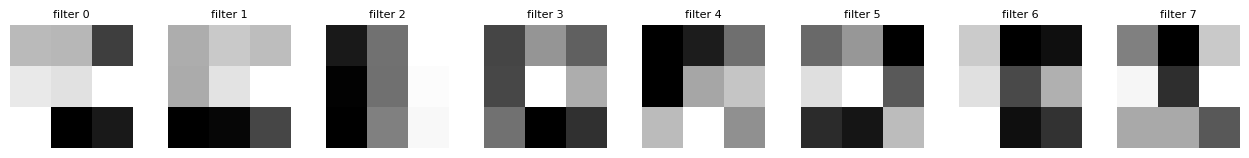

In [37]:
# visualisation of CNN filters
def get_conv_layers(model):
    return [m for m in model.modules() if isinstance(m, nn.Conv2d)]

def plot_conv_filters(model, layer_idx=0, max_filters=None, cmap="gray"):
    conv_layers = get_conv_layers(model)

    if len(conv_layers) == 0:
        raise ValueError("No Conv2d layers found in model.")

    conv = conv_layers[layer_idx]

    # weight shape: (out_channels, in_channels, kernel_h, kernel_w)
    weights = conv.weight.detach().cpu()

    n_filters = weights.shape[0]
    in_channels = weights.shape[1]

    if max_filters is not None:
        n_filters = min(n_filters, max_filters)
        weights = weights[:n_filters]

    cols = min(8, n_filters)
    rows = math.ceil(n_filters / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.6))
    if rows * cols == 1:
        axes = np.array([[axes]])
    else:
        axes = np.array(axes).reshape(rows, cols)

    for i in range(rows * cols):
        ax = axes[i // cols][i % cols]

        if i < n_filters:
            filt = weights[i]

            # MNIST first layer usually has in_channels=1
            if in_channels == 1:
                img = filt[0]
            else:
                # for later conv layers, average across input channels for simple visualisation
                img = filt.mean(dim=0)

            ax.imshow(img, cmap=cmap)
            ax.set_title(f"filter {i}", fontsize=8)

        ax.axis("off")

    plt.tight_layout()
    plt.show()

# visualise for model
plot_conv_filters(model)